# EDA — AAPL Stock Price
Exploratory analysis on `data/processed/processed_stock.csv`.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path

sns.set_style("whitegrid")
%matplotlib inline

# Notebook lives in notebooks/, so project root is one level up
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed" / "processed_stock.csv"

df = pd.read_csv(PROCESSED_DATA, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Log_Return,SMA_10,SMA_20,...,BB_Upper,BB_Lower,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_5,Close_lag_10,DayOfWeek,Month,Target_Next_Close
0,2010-10-18,9.519469,9.549404,9.408408,9.533539,1093010800,0.010358,0.010305,8.952219,8.761456,...,9.363333,8.159580,9.421876,9.049779,8.984819,8.841727,8.341209,0,10,9.264714
1,2010-10-19,9.264714,9.392838,8.981226,9.082408,1232784000,-0.026761,-0.027126,9.013737,8.799953,...,9.427936,8.171969,9.519469,9.421876,9.049779,8.936921,8.649541,1,10,9.295849
2,2010-10-20,9.295849,9.407209,9.186286,9.250048,721624400,0.003361,0.003355,9.077619,8.834049,...,9.492801,8.175298,9.264714,9.519469,9.421876,8.984819,8.657025,2,10,9.265614
3,2010-10-21,9.265614,9.421876,9.184189,9.350630,551460000,-0.003253,-0.003258,9.138388,8.864883,...,9.544550,8.185216,9.295849,9.264714,9.519469,9.049779,8.657926,3,10,9.204247
4,2010-10-22,9.204247,9.281180,9.169222,9.252143,372778000,-0.006623,-0.006645,9.178502,8.887559,...,9.581305,8.193813,9.265614,9.295849,9.264714,9.421876,8.803111,4,10,9.245257


## 1. Basic checks

In [5]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
df[["Open", "High", "Low", "Close", "Volume"]].describe()

Shape: (3823, 27)

Missing values:
 Series([], dtype: int64)


,Open,High,Low,Close,Volume
count,3823.000000,3823.000000,3823.000000,3823.000000,3.823000e+03
mean,80.842230,81.710850,80.033980,80.910498,1.969143e+08
std,74.857654,75.665285,74.131284,74.939474,1.884509e+08
min,9.016551,9.100071,8.913574,8.995597,1.791060e+07
25%,21.112452,21.272828,20.897641,21.104931,7.587780e+07
50%,40.877182,41.165891,40.579861,40.909920,1.244237e+08
75%,145.117214,146.384328,143.608885,145.326195,2.557468e+08
max,285.669263,288.084759,282.774617,285.659271,1.880998e+09


In [6]:
# Date continuity: gaps larger than a normal weekend
gaps = df["Date"].diff().dt.days
gaps.sort_values(ascending=False).head(10)

513     5.0
2580    4.0
3073    4.0
3241    4.0
2416    4.0
3082    4.0
2696    4.0
2947    4.0
3384    4.0
2632    4.0
Name: Date, dtype: float64

## 2. Price trend with moving averages

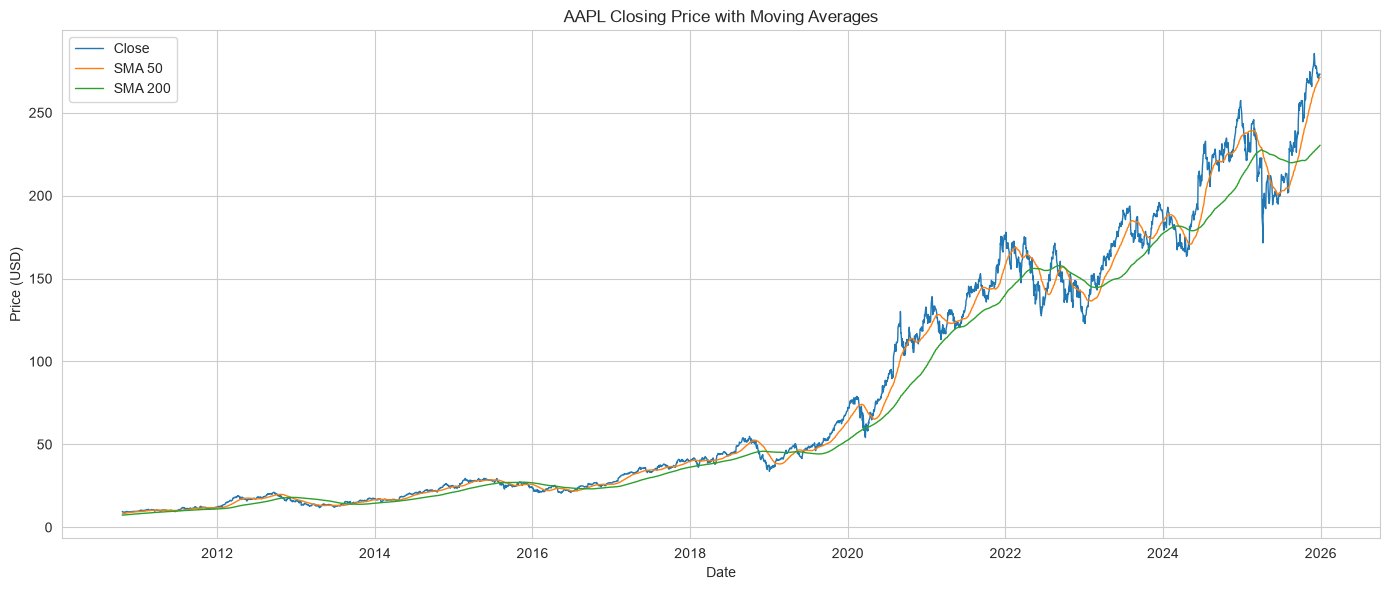

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"], label="Close", linewidth=1)
plt.plot(df["Date"], df["SMA_50"], label="SMA 50", linewidth=1)
plt.plot(df["Date"], df["SMA_200"], label="SMA 200", linewidth=1)
plt.title("AAPL Closing Price with Moving Averages")
plt.xlabel("Date"); plt.ylabel("Price (USD)"); plt.legend()
plt.tight_layout()
plt.show()

## 3. Trading volume over time

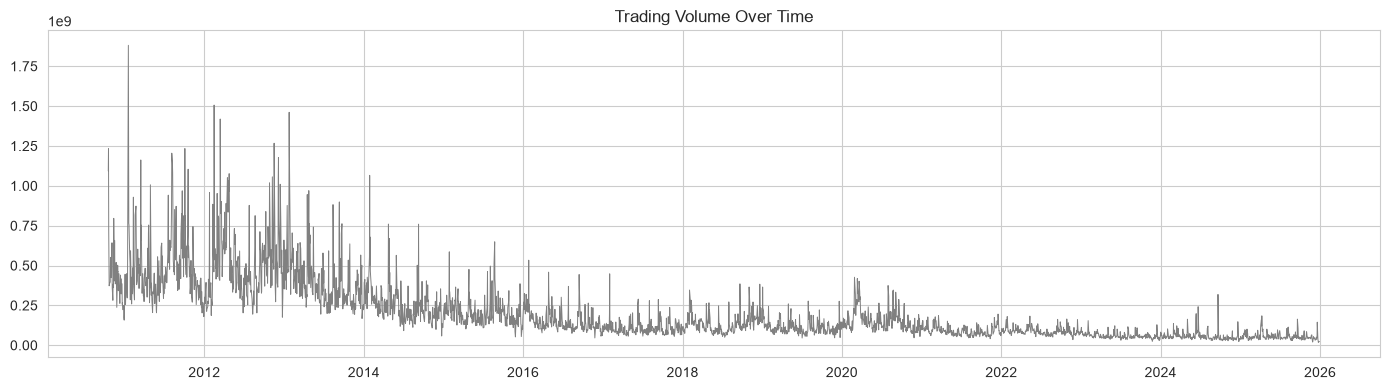

In [8]:
plt.figure(figsize=(14, 4))
plt.plot(df["Date"], df["Volume"], color="gray", linewidth=0.7)
plt.title("Trading Volume Over Time")
plt.tight_layout()
plt.show()

## 4. Return distribution
Stock returns are rarely normal — check skew/kurtosis.

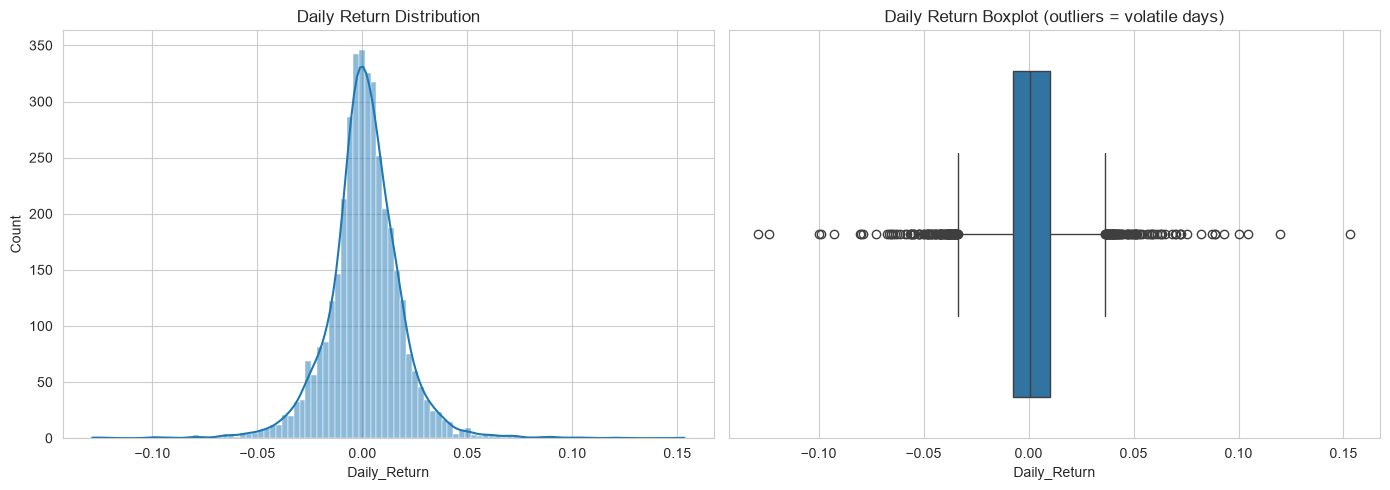

Skew: 0.0596166619574476
Kurtosis: 6.433004264095905


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Daily_Return"].dropna(), bins=100, kde=True, ax=axes[0])
axes[0].set_title("Daily Return Distribution")
sns.boxplot(x=df["Daily_Return"].dropna(), ax=axes[1])
axes[1].set_title("Daily Return Boxplot (outliers = volatile days)")
plt.tight_layout()
plt.show()

print("Skew:", df["Daily_Return"].skew())
print("Kurtosis:", df["Daily_Return"].kurtosis())

## 5. Rolling volatility (risk clustering)

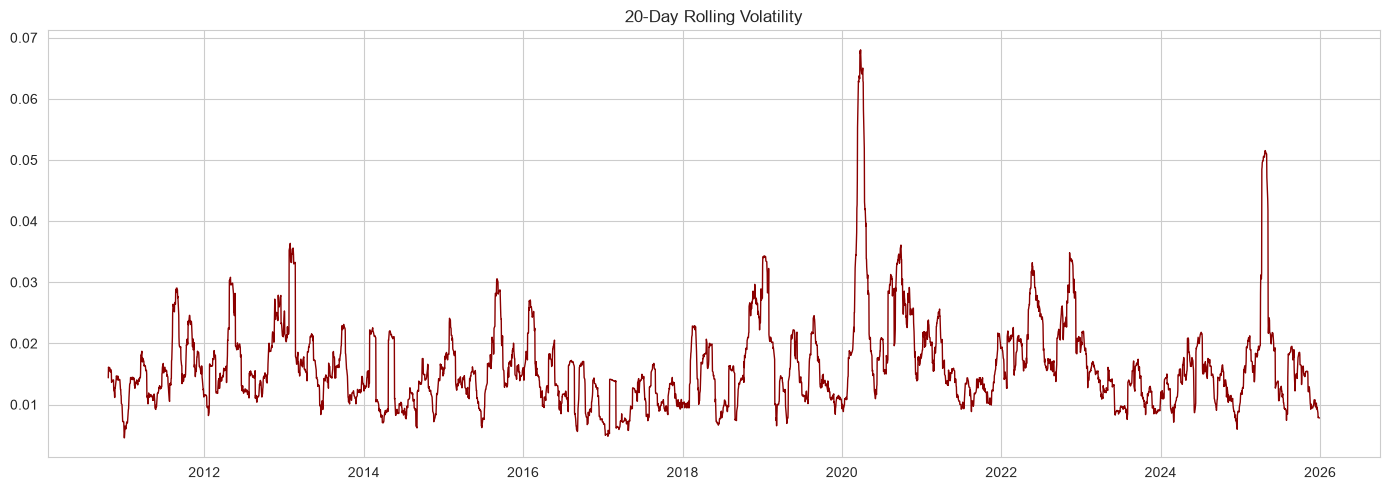

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Volatility_20"], color="darkred", linewidth=1)
plt.title("20-Day Rolling Volatility")
plt.tight_layout()
plt.show()

## 6. ACF / PACF of returns
Is there any exploitable autocorrelation, or is this close to a random walk?

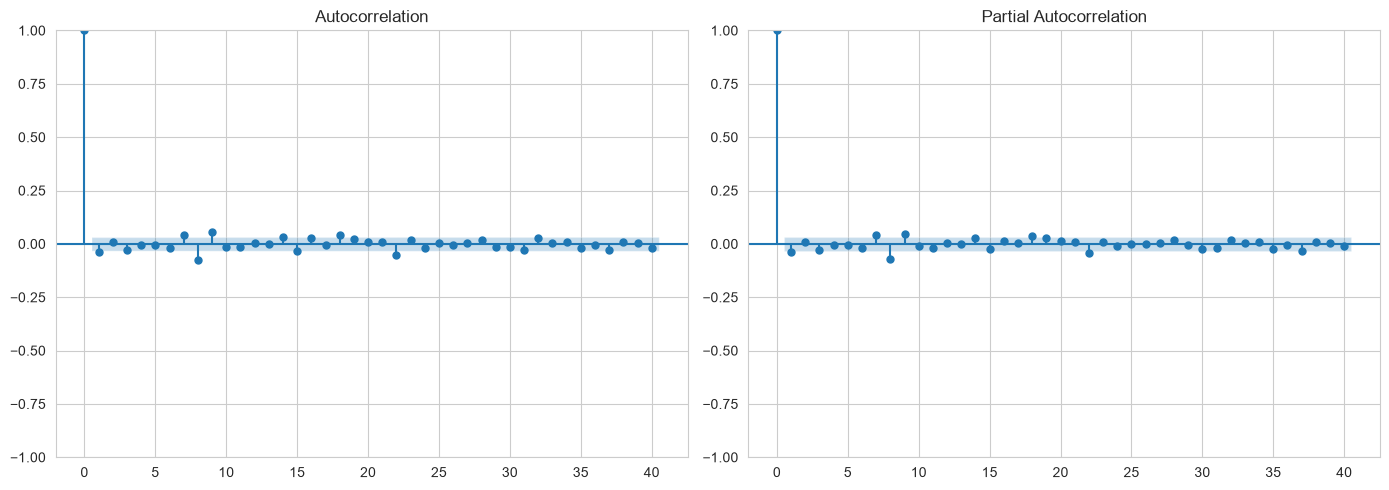

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df["Daily_Return"].dropna(), lags=40, ax=axes[0])
plot_pacf(df["Daily_Return"].dropna(), lags=40, ax=axes[1])
plt.tight_layout()
plt.show()

## 7. Correlation heatmap of engineered features

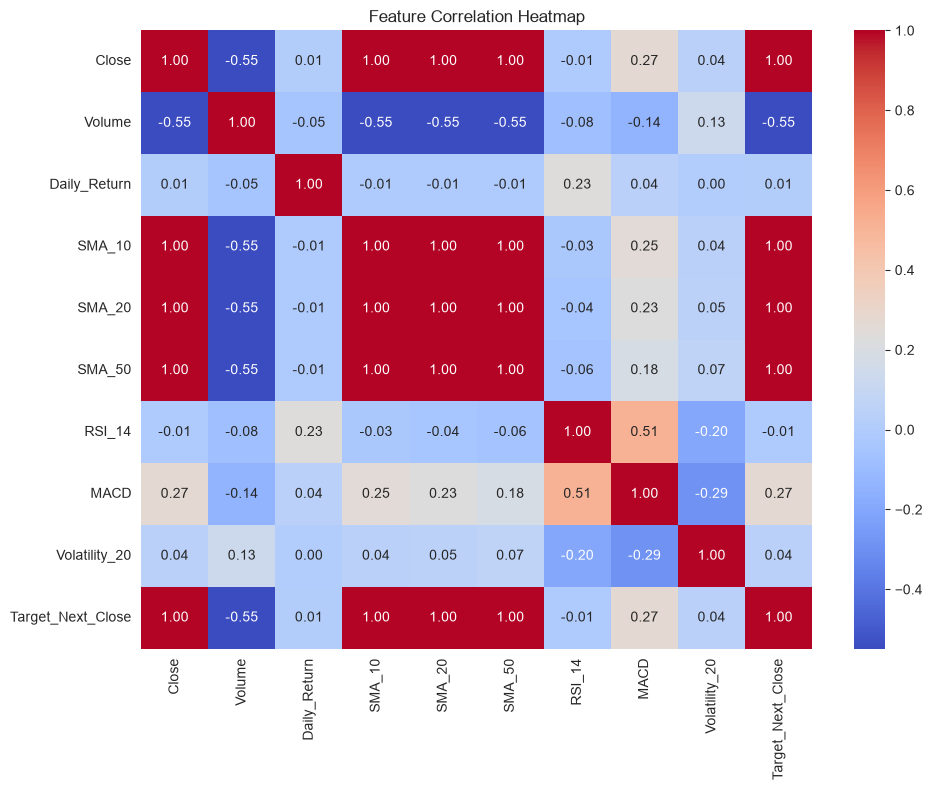

In [12]:
feature_cols = ["Close", "Volume", "Daily_Return", "SMA_10", "SMA_20", "SMA_50",
                "RSI_14", "MACD", "Volatility_20", "Target_Next_Close"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 8. Seasonal decomposition

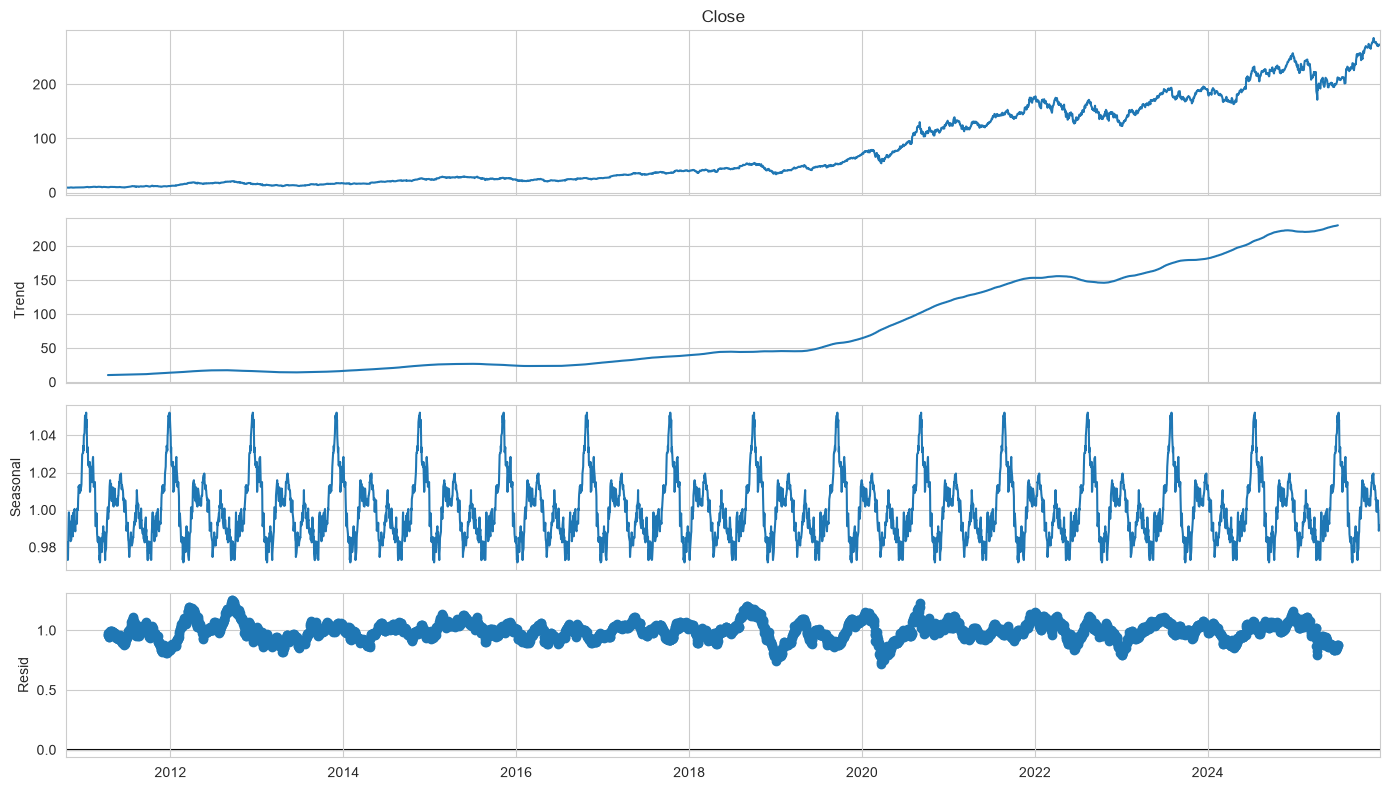

In [13]:
series = df.set_index("Date")["Close"].asfreq("B").ffill()
decomposition = seasonal_decompose(series, model="multiplicative", period=252)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

## Notes / Takeaways

**Data quality**
- Dataset covers ___ rows from 2010-01-01 to 2025-12-31, no missing values found.
- Date gaps were limited to normal weekends/holidays (largest gap ___ days), 
  so no data quality issues.

**Price trend**
- AAPL shows a strong long-term uptrend, with the SMA-50 crossing above SMA-200 
  (a "golden cross") multiple times, most notably around ___.
- [Note the biggest visible run-ups/dips, e.g. 2020 crash, 2022 decline]

**Volume**
- Volume shows [spikes around earnings dates / declining trend over time / 
  no clear pattern] — note anything visually obvious.

**Return distribution**
- Daily return skew: ___ (near 0 = symmetric; negative = more extreme down days 
  than up days, which is typical for equities)
- Kurtosis: ___ (positive/high kurtosis means "fat tails" — more extreme moves 
  than a normal distribution would predict, which is standard for stock returns)
- This confirms stock returns are **not normally distributed**, which is why 
  models assuming normality (like some classical time series models) need care.

**Volatility**
- The 20-day rolling volatility shows clear clustering — calm periods followed 
  by spikes, rather than constant volatility.
- Largest volatility spike appears around ___ (likely March 2020 / COVID crash, 
  or other major market event visible in your date range).

**Autocorrelation (ACF/PACF)**
- [Fill in: did you see any bars outside the confidence band, or basically 
  nothing significant beyond lag 0?]
- If mostly insignificant: this supports the idea that daily returns are close 
  to a random walk — meaning simple lag-based prediction of returns won't work 
  well, and this is *why* the naive baseline is hard to beat later in modeling.

**Correlation heatmap**
- Which features correlated most strongly with Target_Next_Close? (Likely 
  Close, SMA_10/20/50, and lag features — since tomorrow's price is naturally 
  close to today's price.)
- Volume and RSI typically show weak correlation with the target directly — 
  worth noting as an observation.

**Seasonal decomposition**
- Trend component confirms the long-term uptrend already seen.
- [Note if the seasonal component looks meaningful or mostly noise — for daily 
  stock prices it's often not strongly seasonal in a calendar sense]

**Implication for modeling**
- Given the near-random-walk behavior, the naive baseline (today's price = 
  tomorrow's prediction) will be a tough benchmark to beat on RMSE.
- Directional accuracy is likely a more meaningful metric than raw price error 
  for this dataset.